In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:
problem_name = "sphere"
log_file = problem_name + "_log.csv"

data = pd.read_csv(log_file,sep=",")
#strip whiet spaces from column names and all column values
data.columns = data.columns.str.strip()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].str.strip()

data['n_vertices'] = data['n_vertices'].astype(int)
data['num_non_zeros'] = data['num_non_zeros'].astype(int)
data['max_e_length'] = data['max_e_length'].astype(float)
data['l2_res_norm'] = data['l2_res_norm'].astype(float)





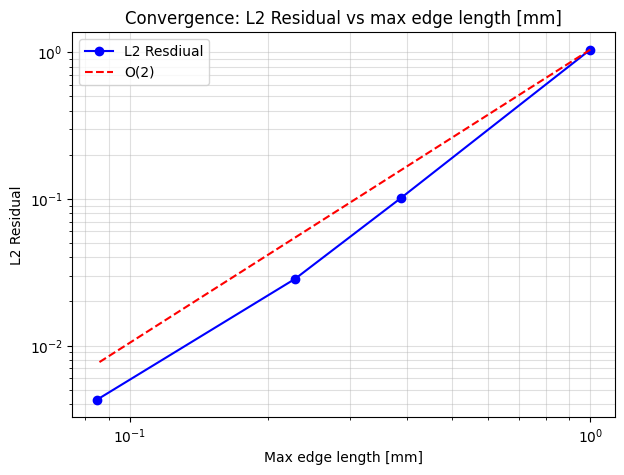

In [10]:
error_arr = data['l2_res_norm'].values
e_length_arr = data['max_e_length'].values

plt.figure(figsize=(7, 5))
plt.loglog(e_length_arr, error_arr, 'bo-', label='L2 Resdiual')

ref_line_max = [error_arr[0] * (v / e_length_arr[0])**(2) for v in e_length_arr]
plt.loglog(e_length_arr, ref_line_max, 'r--', label='O(2)')

plt.xlabel('Max edge length [mm]')
plt.ylabel('L2 Residual')
plt.title('Convergence: L2 Residual vs max edge length [mm]')
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()
plt.show()